# Customer Churn Prediction

## Objective
To predict whether a customer will churn (leave the company)
based on demographic and service usage data.

This project focuses on handling imbalanced data
and evaluating models using business-relevant metrics.


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

%matplotlib inline
sns.set_style("whitegrid")

In [57]:
df = pd.read_csv("../data/customer_churn.csv")
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [58]:
df.shape

(7043, 21)

In [59]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## What does one row represent?

## Which column is the target?

👉 Target = Churn

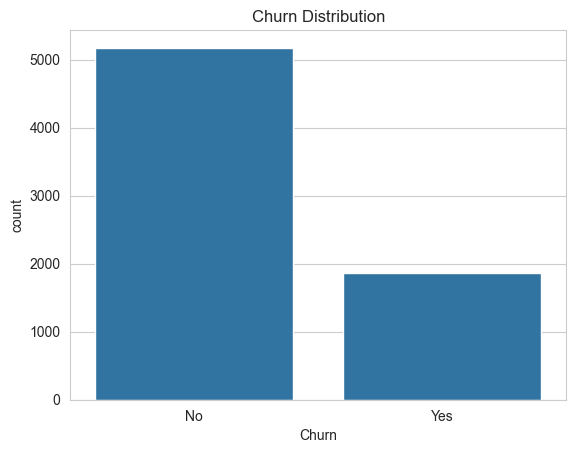

In [60]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


## Is churn balanced?

## Approximate churn percentage?

In [61]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## ✍️ Any strange values?

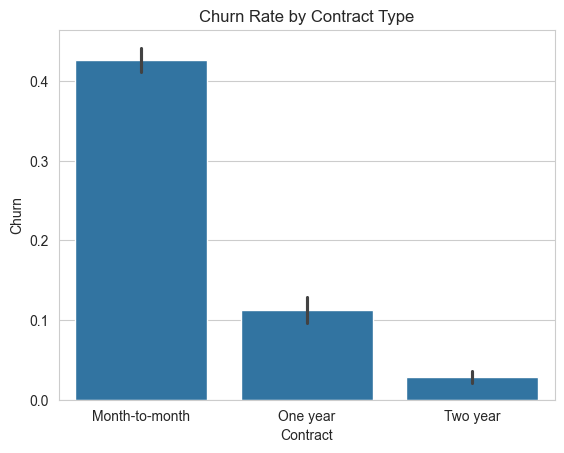

In [62]:
sns.barplot(x='Contract', y=df['Churn'].map({'Yes':1,'No':0}), data=df)
plt.title("Churn Rate by Contract Type")
plt.show()


## Which contract churns more?

## Business interpretation?

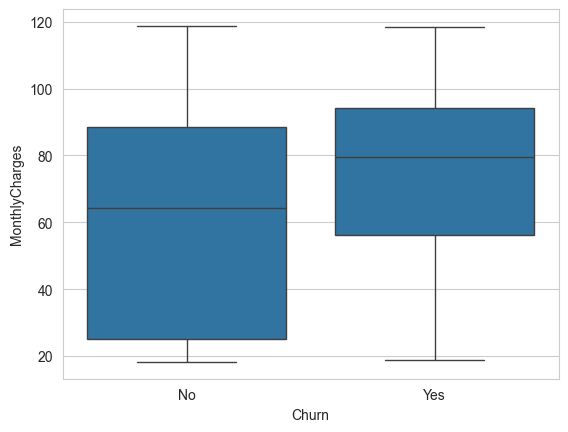

In [63]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()


## Who pays more? Who churns?

In [64]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [65]:
data = pd.read_csv("../data/customer_churn.csv")
data = data.drop(columns=["customerID"])
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [66]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [67]:
# data["gender"] = data["gender"].map({"Female":0,"Male":1})
# data["Partner"] = data["Partner"].map({"Yes":1,"No":0})
# data["Dependents"] = data["Dependents"].map({"Yes":1,"No":0})
# data["PhoneService"] = data["PhoneService"].map({"Yes":1,"No":0})
# data["OnlineSecurity"] = data["OnlineSecurity"].map({"Yes":1,"No":0})
# data["OnlineBackup"] = data["OnlineBackup"].map({"Yes":1,"No":0})
# data["DeviceProtection"] = data["DeviceProtection"].map({"Yes":1,"No":0})
# data["TechSupport"] = data["TechSupport"].map({"Yes":1,"No":0})
# data["StreamingTV"] = data["StreamingTV"].map({"Yes":1,"No":0})
# data["StreamingMovies"] = data["StreamingMovies"].map({"Yes":1,"No":0})
# data["PaperlessBilling"] = data["PaperlessBilling"].map({"Yes":1,"No":0})
# data.head()

In [68]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [69]:
# # Fix TotalCharges
# data["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# # Handle missing values created by conversion
# data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)

# # Convert target
# data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

In [70]:
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

In [71]:
x = data.drop(columns=["Churn"])
y = data["Churn"]
print(x)
print(y)

      gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0     Female              0     Yes         No       1           No   
1       Male              0      No         No      34          Yes   
2       Male              0      No         No       2          Yes   
3       Male              0      No         No      45           No   
4     Female              0      No         No       2          Yes   
...      ...            ...     ...        ...     ...          ...   
7038    Male              0     Yes        Yes      24          Yes   
7039  Female              0     Yes        Yes      72          Yes   
7040  Female              0     Yes        Yes      11           No   
7041    Male              1     Yes         No       4          Yes   
7042    Male              0      No         No      66          Yes   

         MultipleLines InternetService OnlineSecurity OnlineBackup  \
0     No phone service             DSL             No          Yes   
1      

In [72]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 19)
(1409, 19)
(5634,)
(1409,)


In [73]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer

num_features = x.select_dtypes(include=["int64","float64"]).columns
cat_features = x.select_dtypes(include=["object"]).columns

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

C:\Users\nigam\AppData\Local\Temp\ipykernel_3676\2857213218.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = x.select_dtypes(include=["object"]).columns


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=50,
        n_jobs=-1,
        class_weight="balanced"
    ),
    "GradientBoosting": GradientBoostingClassifier(n_estimators=200),
    "SVM": SVC(class_weight="balanced")
}


In [75]:
from sklearn.metrics import accuracy_score,f1_score,classification_report

results = []

try:
    for name, model in models.items():
        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(x_train, y_train)
        pred = pipe.predict(x_test)

        f1 = f1_score(y_test, pred)
        accuracy_score(y_test,pred)

        print(f"\n{name}")
        print(classification_report(y_test, pred))

        results.append({
            "Model": name,
            "F1-Score": f1
        })
except Exception as e:
    print(f"{name} failed as {e}")
    
pd.DataFrame(results)          


LogisticRegression
              precision    recall  f1-score   support

           0       0.91      0.77      0.83      1036
           1       0.55      0.79      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409


RandomForest
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1036
           1       0.63      0.61      0.62       373

    accuracy                           0.80      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409


GradientBoosting
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.70      0.52      0.59       373

    accuracy                           0.81      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.8

,Model,F1-Score
0,LogisticRegression,0.649780
1,RandomForest,0.619178
2,GradientBoosting,0.594761
3,SVM,0.637131


## LogisticRegression is best model with:
                            (max_iter=1000,
                             class_weight="balanced")